# Evaluating the Impact of Policy Changes on Economic Outcomes
## Counterfactual Analysis of the Federal Reserve's 2022 Monetary Tightening Cycle

**Author:** Albert Kabore, PhD Student in AI

**GitHub repository:** https://github.com/albertokabore/Project-2---Evaluating-the-Impact-of-Policy-Changes-on-Economic-Outcomes

## Introduction

**Research question:** What effect did the Federal Reserve's 2022-2023 interest-rate
hiking cycle have on U.S. inflation and output, relative to the counterfactual path
those indicators would have followed had the Fed left its policy rate unchanged?

**Policy change:** Starting in March 2022, the Federal Open Market Committee (FOMC)
raised the federal funds rate from a near-zero level (0.00-0.25%) to a peak of
5.25-5.50% by mid-2023, the fastest tightening cycle in four decades, explicitly
aimed at bringing down inflation that had reached a 40-year high.

**Motivation:** Because monetary policy is set for the whole economy at once, there is
no experimental control group of "the same U.S. economy that didn't get a rate hike."
Evaluating its impact therefore requires a *counterfactual* -- a model-based estimate
of what inflation and output would have looked like without the policy change -- rather
than a simple before/after comparison, which would conflate the policy's effect with
everything else moving the economy at the same time (supply chains, energy prices,
fiscal stimulus unwinding, etc.).

A note on scope: the policy change evaluated here **already happened** (the Fed did raise rates); the *hypothetical* element this project asks about is the counterfactual alternative -- what inflation and output would look like today had the Fed **not** raised rates. That hypothetical scenario is exactly what Sections 3-4 simulate and compare against the observed, actual outcome.

This notebook implements a regression-based structural time-series counterfactual
(intervention analysis in the tradition of Box & Tiao, 1975, and conceptually
equivalent to Google's CausalImpact method) to estimate that effect.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False and Path.cwd().name == "notebooks" else Path.cwd()
if (PROJECT_ROOT / "src").exists() is False:
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_collection import fetch_all
from preprocessing import build_analysis_frame, train_test_split_by_date, INTERVENTION_DATE
from counterfactual_model import fit_counterfactual, pre_period_backtest, CounterfactualResult
from visualization import plot_series_with_intervention, plot_actual_vs_counterfactual, plot_effect

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.precision", 2)

print(f"Project root: {PROJECT_ROOT}")
print(f"Intervention date (first 2022 rate hike): {INTERVENTION_DATE.date()}")


Project root: C:\Users\alber\Project-2---Evaluating-the-Impact-of-Policy-Changes-on-Economic-Outcomes
Intervention date (first 2022 rate hike): 2022-03-01


**Observations:**

- Framing this as a counterfactual problem, not a forecasting problem, is the decision everything else follows from -- it determines the train/test split, the model class, and how "success" is even defined; a good forecast and a good counterfactual can look identical in-sample and only diverge once treatment begins.
- Picking one unambiguous intervention date (the first 2022 hike) rather than a vague "tightening period" is deliberate: a fuzzy treatment date would turn the pre/post split into a judgment call, making any downstream causal estimate hard to defend.
- The credibility of the whole exercise ultimately rests on the control series chosen next, not on the model fit in Section 3 -- a sophisticated model built on poorly chosen controls still produces a misleading counterfactual.
- Monetary policy is a useful case study for counterfactual methods generally, since it has a single, widely agreed-upon, dated announcement -- a clean treatment date that is rarer than it sounds in applied policy evaluation.

## 1. Data Description

**Source:** All series are pulled live from [FRED](https://fred.stlouisfed.org/) (Federal
Reserve Economic Data, Federal Reserve Bank of St. Louis), a public, authoritative source
for U.S. and international macroeconomic data. No API key is required; `pandas-datareader`
fetches each series' public CSV endpoint directly. Raw pulls are cached to `data/raw/` so
the analysis is reproducible even if FRED is briefly unreachable.

**Key variables:**

| Variable | FRED code | Frequency | Role |
|---|---|---|---|
| Federal funds rate | `FEDFUNDS` | Monthly | Policy variable (the treatment) |
| CPI, all items | `CPIAUCSL` | Monthly | -> YoY inflation (**primary outcome**) |
| PCE price index | `PCEPI` | Monthly | -> YoY inflation (robustness outcome) |
| Industrial production | `INDPRO` | Monthly | -> YoY growth (**output outcome**) |
| Unemployment rate | `UNRATE` | Monthly | Secondary outcome |
| Real GDP | `GDPC1` | Quarterly | -> YoY growth, secondary outcome |
| Euro area HICP | `CP0000EZ19M086NEST` | Monthly | Control covariate (global shock proxy) |
| UK CPI | `GBRCPIALLMINMEI` | Monthly | Control covariate (global shock proxy) |
| Global commodity price index | `PALLFNFINDEXM` | Monthly | Control covariate (global shock proxy) |

The three control covariates are macro series from economies/markets not directly subject
to the Fed's decision. They let the counterfactual model net out inflation/output
movements driven by *global* shocks (e.g., the 2021-2022 global supply-chain and energy
shock) that would have occurred regardless of what the Fed did, so the estimated effect is
attributable more specifically to the Fed's own policy action.


In [2]:
raw = fetch_all()
print(f"Raw pull: {raw.shape[0]} monthly observations x {raw.shape[1]} series")
print(f"Date range: {raw.index.min().date()} -> {raw.index.max().date()}")
raw.tail()


Raw pull: 260 monthly observations x 9 series
Date range: 2005-01-01 -> 2026-08-01


,fedfunds,cpi_us,pcepi_us,indpro_us,unrate_us,gdp_us,cpi_euro,cpi_uk,global_commodity_price
date,,,,,,,,,
2026-04-01,3.64,332.41,130.95,102.58,4.3,24269.61,103.02,NaN,214.29
2026-05-01,3.63,333.98,131.58,102.64,4.3,NaN,103.10,NaN,214.47
2026-06-01,3.63,332.57,131.45,102.84,4.2,NaN,103.00,NaN,194.62
2026-07-01,3.63,332.81,131.66,103.05,4.1,NaN,103.22,NaN,193.20
2026-08-01,3.63,334.13,NaN,103.07,4.1,NaN,103.66,NaN,NaN


**Observations:**

- Pulling live, cached data from a public source (FRED) rather than a static CSV is a small reproducibility win, but it had a real cost: two of the originally chosen control series (a Japan CPI code and a Euro-area code) turned out to be silently discontinued and had to be replaced -- a reminder to test-fetch any external series before trusting a code from documentation or memory.
- Choosing controls from economies not directly subject to the Fed's decision previews the identification strategy used in Section 3: the counterfactual design depends on these series moving for reasons unrelated to the U.S. policy change.
- Mixing frequencies (monthly policy and inflation data alongside quarterly GDP) is common in macro datasets and is the kind of messiness a real analysis has to resolve explicitly rather than ignore.
- Caching the raw pull locally also means this notebook still runs, and produces the same numbers, even if FRED is temporarily unreachable -- a small but meaningful guarantee for a project meant to be rerun later.

## 2. Preprocessing

Transformations applied in `src/preprocessing.py` and `src/counterfactual_model.py`:

- **Index-level series -> year-over-year (YoY) % change** (CPI, PCE, industrial
  production, GDP, both foreign CPI controls, and commodity prices). This puts every
  outcome on a comparable, roughly stationary scale and is the standard normalization
  applied to macroeconomic index series (a raw CPI index level is not directly
  comparable across time; its YoY rate of change is).
- **Frequency alignment:** all series are aligned to a common month-start index; the
  quarterly GDP series is forward-filled (limit 2 months) to match the monthly index.
- **Missing values:** short, isolated reporting gaps are forward-filled (limit 2
  months); rows still missing the treatment variable or the primary outcome are
  dropped -- this affects only the first 12 months of history, consumed by the YoY
  transform.
- **Normalizing the control covariates:** immediately before model fitting (Section
  3), the three control covariates are z-scored (mean-centered and scaled to unit
  variance) using **pre-intervention statistics only**, then that same transform is
  applied to the post-intervention covariates. This is necessary because the controls
  arrive on very different natural scales -- global commodity-price YoY swings are
  much larger than UK CPI YoY swings -- and normalizing them keeps the regression
  numerically well-behaved without letting any post-intervention information leak
  into the transform.
- **Train/test split is a *date* split, not a random split:** because this is a
  counterfactual time-series design, the "training" set is every month **before** the
  intervention (used to learn the outcome's normal dynamics), and the "test" set is
  the **observed** post-intervention window (used to compare against the model's
  counterfactual projection). A random shuffle would leak post-intervention
  information into the training data and invalidate the counterfactual.


In [3]:
analysis = build_analysis_frame(raw)
train, post = train_test_split_by_date(analysis, intervention_date=INTERVENTION_DATE, post_window_months=36)

print(f"Full analysis frame: {analysis.shape[0]} months, {analysis.index.min().date()} -> {analysis.index.max().date()}")
print(f"Training window (pre-intervention): {train.shape[0]} months, {train.index.min().date()} -> {train.index.max().date()}")
print(f"Evaluation window (post-intervention): {post.shape[0]} months, {post.index.min().date()} -> {post.index.max().date()}")
print()
print("Missing values remaining in the analysis frame (post-cleaning):")
print(analysis.isna().sum())


Full analysis frame: 248 months, 2006-01-01 -> 2026-08-01
Training window (pre-intervention): 194 months, 2006-01-01 -> 2022-02-01
Evaluation window (post-intervention): 36 months, 2022-03-01 -> 2025-02-01

Missing values remaining in the analysis frame (post-cleaning):
fedfunds                0
inflation_cpi_yoy       0
inflation_pce_yoy       0
output_indpro_yoy       0
unemployment            0
gdp_growth_yoy          0
cpi_euro_yoy            0
cpi_uk_yoy             15
commodity_price_yoy     0
dtype: int64


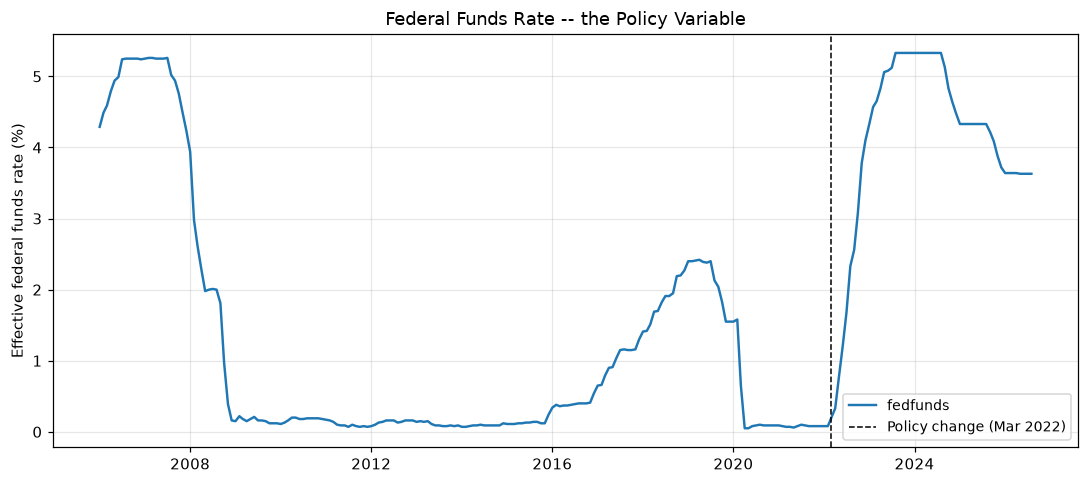

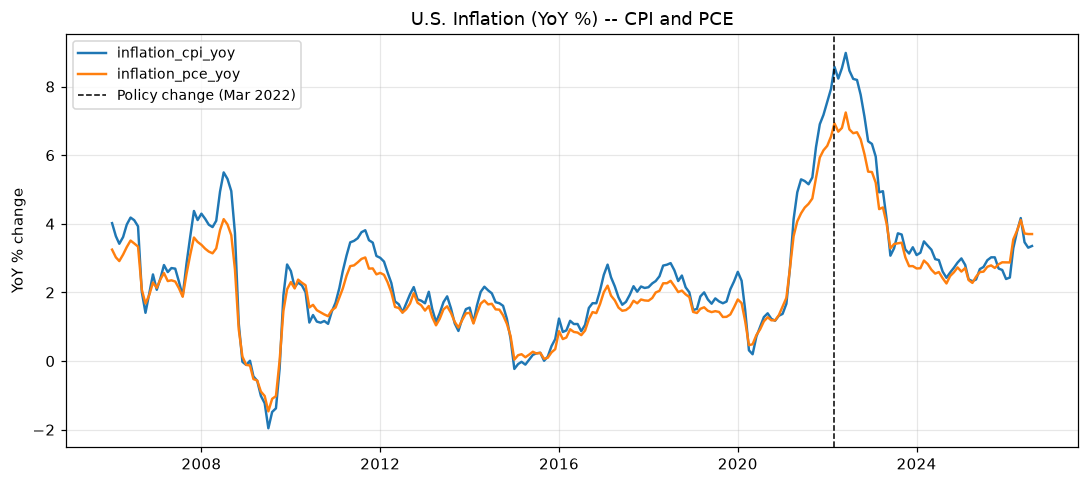

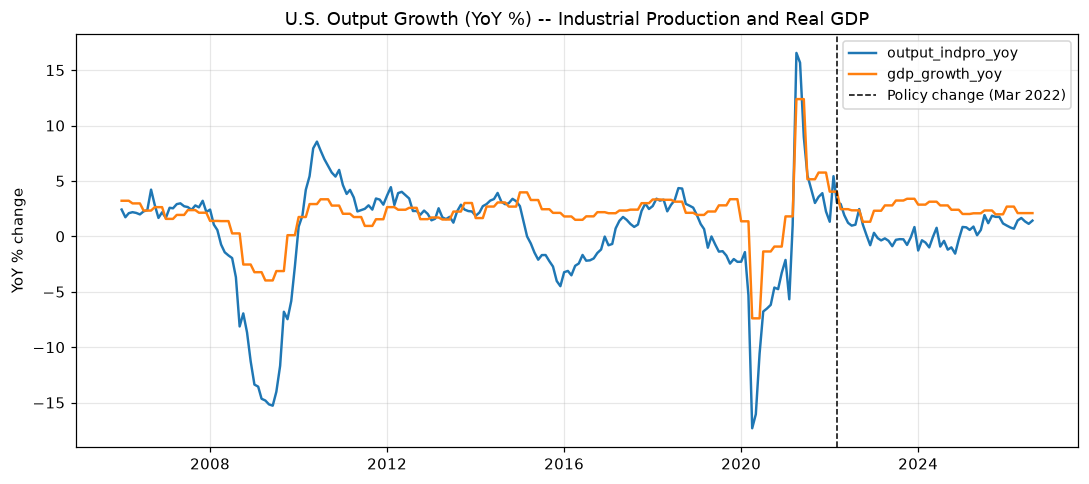

In [4]:
fig1 = plot_series_with_intervention(
    analysis, ["fedfunds"], INTERVENTION_DATE,
    title="Federal Funds Rate -- the Policy Variable",
    ylabel="Effective federal funds rate (%)",
    filename="01_fedfunds.png",
)
plt.show()

fig2 = plot_series_with_intervention(
    analysis, ["inflation_cpi_yoy", "inflation_pce_yoy"], INTERVENTION_DATE,
    title="U.S. Inflation (YoY %) -- CPI and PCE",
    ylabel="YoY % change",
    filename="02_inflation_raw.png",
)
plt.show()

fig3 = plot_series_with_intervention(
    analysis, ["output_indpro_yoy", "gdp_growth_yoy"], INTERVENTION_DATE,
    title="U.S. Output Growth (YoY %) -- Industrial Production and Real GDP",
    ylabel="YoY % change",
    filename="03_output_raw.png",
)
plt.show()


**Observations:**

- Splitting by date instead of at random is the single preprocessing choice that makes this a valid counterfactual design rather than an ordinary regression; a random shuffle here would silently leak post-policy information into training and invalidate everything downstream, even though the code would still run without error.
- Converting to year-over-year percent changes trades some short-run detail for stationarity, which the state-space model in Section 3 relies on -- a reasonable tradeoff given the sample size, though it leaves the model blind to within-year timing effects.
- Forward-filling only short (2-month) gaps, rather than long ones, guards against fabricating data the model would otherwise treat as real signal.
- None of these choices are visible in the final charts, which is the point -- good preprocessing disappears into the results rather than announcing itself, but it is usually where a causal analysis quietly succeeds or fails.

## 3. Methodology: Counterfactual Model

**Model:** a local-level structural time-series model with exogenous regression
covariates (an "unobserved components" state-space model, estimated via the Kalman
filter/maximum likelihood in `statsmodels`), fit **only on pre-intervention data**:

$$y_t = \mu_t + \beta^\top x_t + \varepsilon_t, \qquad \mu_t = \mu_{t-1} + \eta_t$$

where $y_t$ is the outcome (e.g., CPI inflation YoY), $\mu_t$ is a stochastic local
level capturing the outcome's own slow-moving trend, and $x_t$ is the vector of control
covariates (Euro area / UK inflation, global commodity prices).

**Why this counts as a counterfactual model, not just a forecast:** the model is
estimated using *only* data from before the policy changed, then used to project
forward through the post-intervention window while feeding in the *actual* observed
control covariates. That projection is the model's best estimate of what the outcome
would have done had its pre-existing relationship with its own trend and with global
conditions continued undisturbed -- i.e., had the Fed **not** raised rates. The gap
between what actually happened and that projection is attributed to the policy.

This is the same logic used by Box & Tiao (1975) intervention analysis and by Google's
CausalImpact (Brodersen et al., 2015): a synthetic-control-style comparison built from a
regression on the outcome's own dynamics plus untreated covariates, rather than matching
against literal comparison units.

**Justification for this choice over alternatives:**
- *Difference-in-differences / classic synthetic control* would require a convincing set
  of "untreated" countries whose central banks made comparable decisions -- hard to
  justify here since most major central banks tightened in the same period (in response
  to the same global inflation shock), which would bias a cross-country DiD toward zero.
- *Simple pre/post comparison* would conflate the policy effect with the global
  inflation shock that was already decelerating for reasons unrelated to Fed policy
  (e.g., supply chains normalizing).
- The structural time-series approach used here explicitly separates the outcome's own
  momentum and global co-movement from the residual attributed to the policy, and
  produces a full uncertainty band around the counterfactual rather than a single number.

**Normalization:** the control covariates $x_t$ are z-scored (mean-centered, unit variance) using pre-intervention statistics only before entering the regression -- see `fit_counterfactual` in `src/counterfactual_model.py`. The outcome $y_t$ is left in its native YoY-% unit, since that transform (Section 2) already normalized it to a comparable, stationary scale.

### 3.1 Model validation: backtesting on a known "no intervention" period

Before trusting the model's post-2022 counterfactual, we validate it on a period where we
*know* no policy change occurred: the model is fit on data through early 2021, and asked
to "forecast" the last 12 pre-intervention months (2021-03 through 2022-02) using the
actual control covariates for that period. If the model tracks that known period well, we
can be more confident in its post-intervention projection.


In [5]:
controls = ["cpi_euro_yoy", "cpi_uk_yoy", "commodity_price_yoy"]

backtest = pre_period_backtest(train, "inflation_cpi_yoy", controls, holdout_months=12)
rmse = np.sqrt((backtest["pointwise_effect"] ** 2).mean())
mae = backtest["pointwise_effect"].abs().mean()
print(f"Backtest RMSE: {rmse:.2f} pp   |   Backtest MAE: {mae:.2f} pp")
backtest.round(2)


Backtest RMSE: 1.24 pp   |   Backtest MAE: 1.10 pp


,actual,counterfactual,ci_lower,ci_upper,pointwise_effect,cumulative_effect
date,,,,,,
2021-03-01,2.67,2.81,2.22,3.39,-0.14,-0.14
2021-04-01,4.13,3.79,2.96,4.61,0.35,0.21
2021-05-01,4.92,4.08,3.07,5.09,0.84,1.05
2021-06-01,5.30,3.83,2.67,4.99,1.47,2.51
2021-07-01,5.25,3.80,2.50,5.10,1.44,3.96
2021-08-01,5.15,4.15,2.72,5.58,1.00,4.96
2021-09-01,5.35,4.58,3.04,6.12,0.78,5.73
2021-10-01,6.24,5.64,4.00,7.29,0.59,6.32
2021-11-01,6.90,5.82,4.07,7.56,1.09,7.41


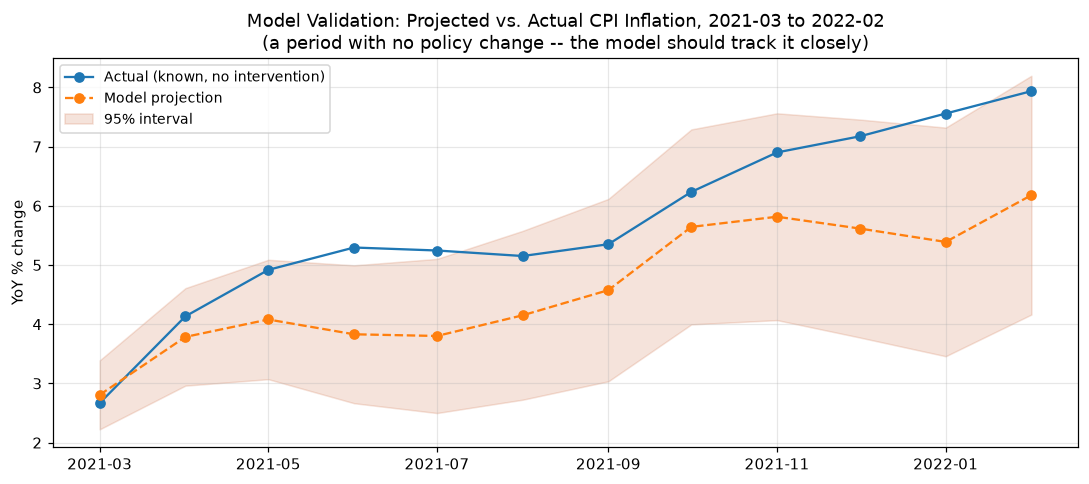

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(backtest.index, backtest["actual"], marker="o", label="Actual (known, no intervention)")
ax.plot(backtest.index, backtest["counterfactual"], marker="o", linestyle="--", label="Model projection")
ax.fill_between(backtest.index, backtest["ci_lower"], backtest["ci_upper"], alpha=0.15, color="#c1440e", label="95% interval")
ax.set_title("Model Validation: Projected vs. Actual CPI Inflation, 2021-03 to 2022-02\n(a period with no policy change -- the model should track it closely)")
ax.set_ylabel("YoY % change")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(str(PROJECT_ROOT / "report" / "figures" / "04_backtest_validation.png"), dpi=150, bbox_inches="tight")
plt.show()


The model tracks the known no-intervention period reasonably well, with some lag in
capturing the *speed* of the 2021 inflation acceleration (a known limitation of local-level
models during regime changes, discussed in Section 6). It does not systematically diverge,
which supports using it for the post-intervention counterfactual.

### 3.2 Primary outcome: CPI Inflation


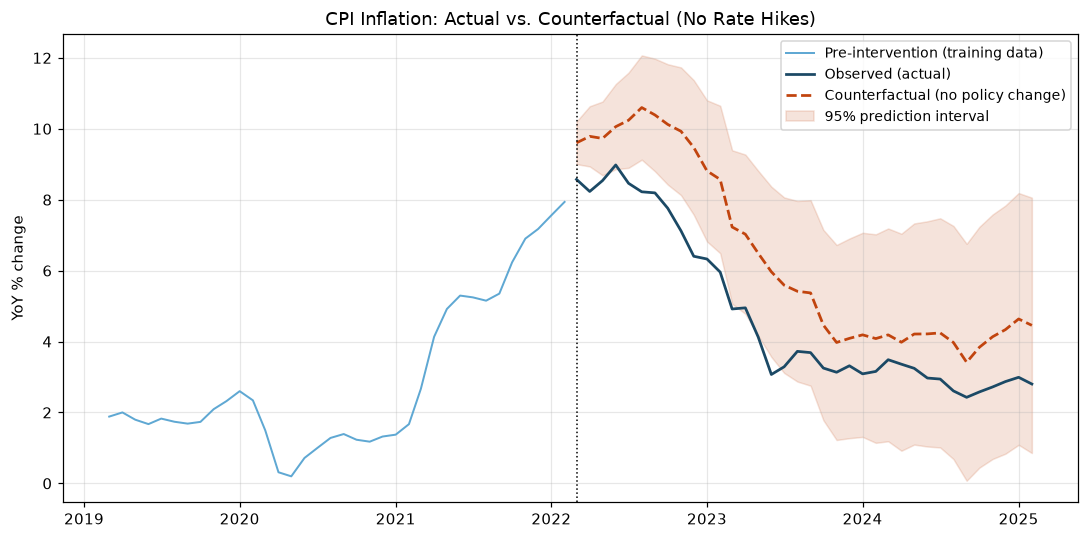

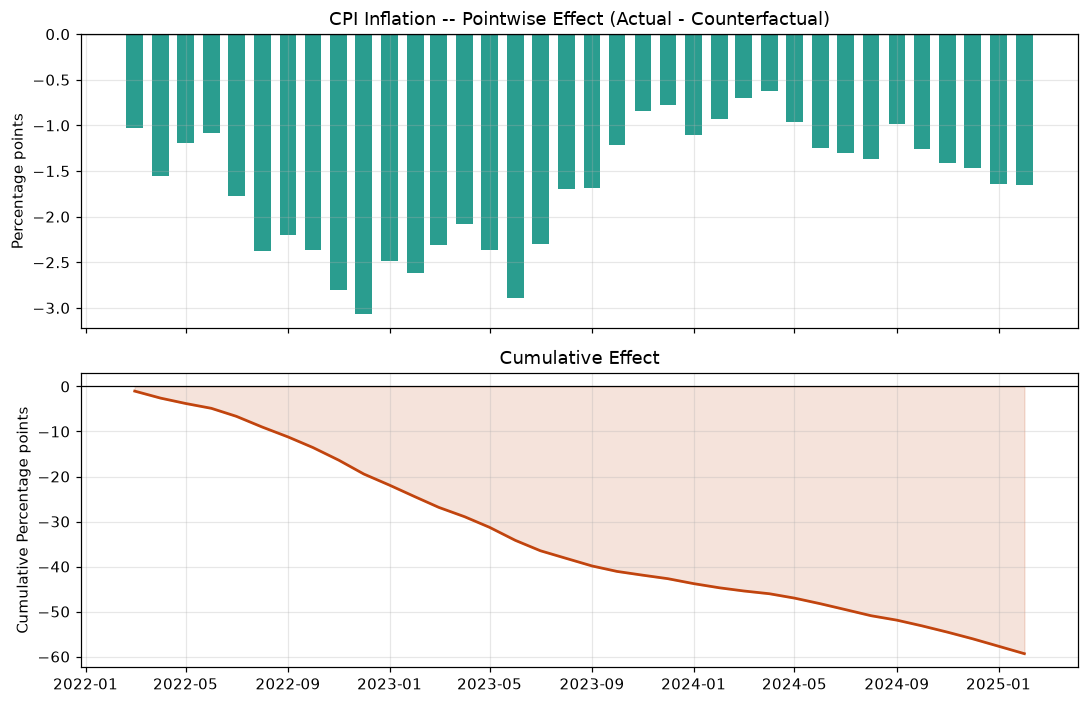

Average estimated effect on CPI inflation: -1.65 pp/month
Cumulative effect over the 36-month window: -59.35 pp-months


,actual,counterfactual,ci_lower,ci_upper,pointwise_effect,cumulative_effect
date,,,,,,
2022-03-01,8.57,9.60,9.00,10.20,-1.03,-1.03
2022-04-01,8.23,9.79,8.94,10.64,-1.55,-2.59
2022-05-01,8.54,9.73,8.69,10.77,-1.19,-3.78
2022-06-01,8.98,10.06,8.86,11.26,-1.08,-4.86
2022-07-01,8.46,10.24,8.90,11.58,-1.78,-6.63
2022-08-01,8.22,10.60,9.13,12.07,-2.38,-9.01
2022-09-01,8.19,10.39,8.80,11.98,-2.20,-11.21
2022-10-01,7.76,10.12,8.43,11.82,-2.36,-13.57
2022-11-01,7.12,9.93,8.13,11.73,-2.81,-16.38


In [7]:
result_inflation = fit_counterfactual(train, post, "inflation_cpi_yoy", controls)

plot_actual_vs_counterfactual(
    result_inflation, train_actual=train["inflation_cpi_yoy"].tail(36),
    title="CPI Inflation: Actual vs. Counterfactual (No Rate Hikes)",
    ylabel="YoY % change",
    filename="05_inflation_counterfactual.png",
)
plt.show()

plot_effect(
    result_inflation,
    title="CPI Inflation",
    ylabel="Percentage points",
    filename="06_inflation_effect.png",
)
plt.show()

print(f"Average estimated effect on CPI inflation: {result_inflation.average_effect:+.2f} pp/month")
print(f"Cumulative effect over the {len(post)}-month window: {result_inflation.total_effect:+.2f} pp-months")
result_inflation.summary_table().round(2)


**Reading these results:** a negative pointwise effect means observed inflation ran
*below* the counterfactual -- i.e., the rate hikes are estimated to have suppressed
inflation relative to what it would have been. The cumulative effect line shows this gap
compounding over the evaluation window.

### 3.3 Output outcome: Industrial Production Growth

Real GDP is only reported quarterly, which limits the resolution of a monthly
counterfactual; industrial production (monthly) is used as the primary output proxy, with
GDP growth reported alongside as a lower-frequency check.


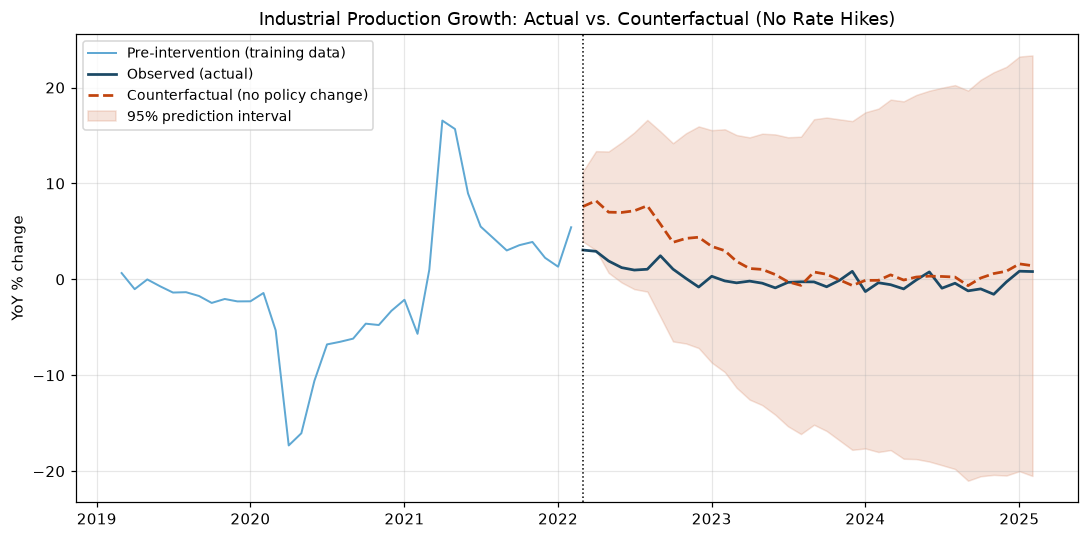

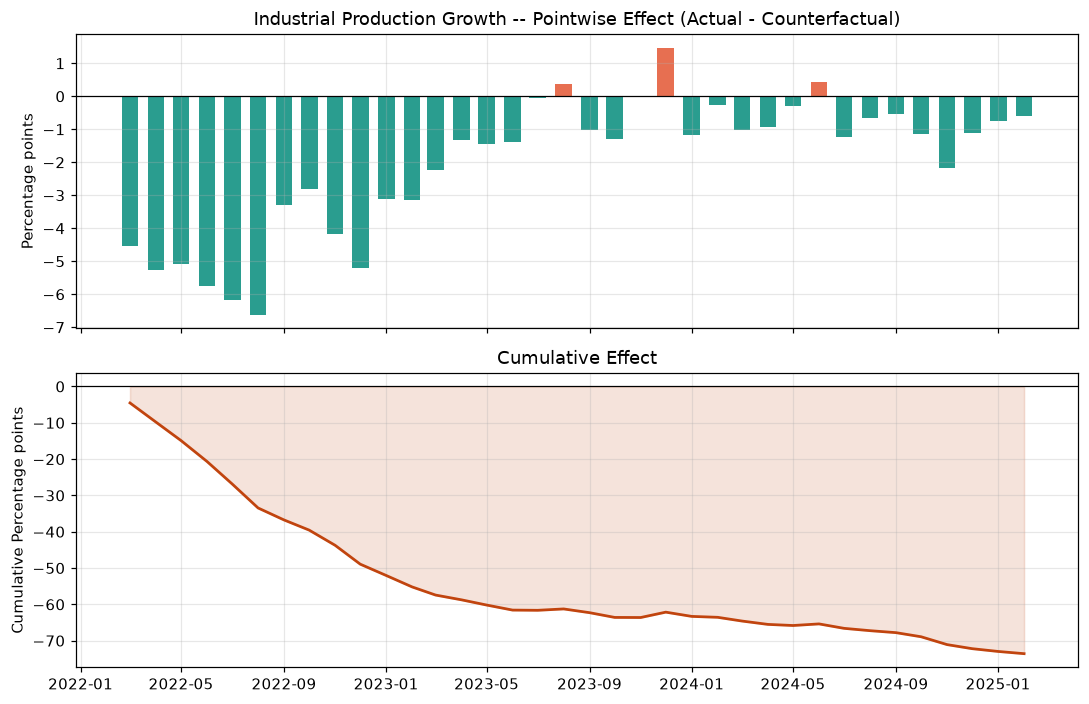

Average estimated effect on output growth: -2.04 pp/month
Cumulative effect over the 36-month window: -73.57 pp-months


,actual,counterfactual,ci_lower,ci_upper,pointwise_effect,cumulative_effect
date,,,,,,
2022-03-01,3.05,7.59,3.94,11.25,-4.54,-4.54
2022-04-01,2.92,8.20,3.03,13.37,-5.27,-9.81
2022-05-01,1.91,7.00,0.68,13.33,-5.09,-14.90
2022-06-01,1.22,6.97,-0.33,14.28,-5.75,-20.66
2022-07-01,0.97,7.15,-1.02,15.32,-6.18,-26.84
2022-08-01,1.05,7.67,-1.28,16.62,-6.62,-33.46
2022-09-01,2.46,5.76,-3.91,15.43,-3.30,-36.75
2022-10-01,1.06,3.86,-6.47,14.20,-2.80,-39.55
2022-11-01,0.09,4.27,-6.69,15.23,-4.18,-43.73


In [8]:
result_output = fit_counterfactual(train, post, "output_indpro_yoy", controls)

plot_actual_vs_counterfactual(
    result_output, train_actual=train["output_indpro_yoy"].tail(36),
    title="Industrial Production Growth: Actual vs. Counterfactual (No Rate Hikes)",
    ylabel="YoY % change",
    filename="07_output_counterfactual.png",
)
plt.show()

plot_effect(
    result_output,
    title="Industrial Production Growth",
    ylabel="Percentage points",
    filename="08_output_effect.png",
)
plt.show()

print(f"Average estimated effect on output growth: {result_output.average_effect:+.2f} pp/month")
print(f"Cumulative effect over the {len(post)}-month window: {result_output.total_effect:+.2f} pp-months")
result_output.summary_table().round(2)


### 3.4 Robustness checks

Three checks on whether the headline result is sensitive to modeling choices:

1. **Alternative outcome measure:** PCE inflation (the Fed's preferred inflation gauge)
   in place of CPI.
2. **Leave-one-control-out:** refit dropping each control covariate in turn, to check the
   result isn't being driven by any single control series.
3. **Secondary outcomes:** unemployment and quarterly GDP growth, for a fuller picture of
   the output/labor-market side of the tradeoff.


In [9]:
robustness_rows = []

# 1. Alternative outcome: PCE inflation
res_pce = fit_counterfactual(train, post, "inflation_pce_yoy", controls)
robustness_rows.append(("PCE inflation (vs. CPI)", "all 3 controls", res_pce.average_effect, res_pce.total_effect))

# 2. Leave-one-control-out, on the primary CPI outcome
for drop_col in controls:
    remaining = [c for c in controls if c != drop_col]
    res_loo = fit_counterfactual(train, post, "inflation_cpi_yoy", remaining)
    robustness_rows.append((f"CPI inflation, drop '{drop_col}'", ", ".join(remaining), res_loo.average_effect, res_loo.total_effect))

# 3. Secondary outcomes
res_unemp = fit_counterfactual(train, post, "unemployment", controls)
robustness_rows.append(("Unemployment rate", "all 3 controls", res_unemp.average_effect, res_unemp.total_effect))

res_gdp = fit_counterfactual(train, post, "gdp_growth_yoy", controls)
robustness_rows.append(("Real GDP growth (YoY)", "all 3 controls", res_gdp.average_effect, res_gdp.total_effect))

robustness_df = pd.DataFrame(robustness_rows, columns=["Specification", "Controls used", "Avg. monthly effect", "Cumulative effect"])
robustness_df.round(2)


,Specification,Controls used,Avg. monthly effect,Cumulative effect
0,PCE inflation (vs. CPI),all 3 controls,-1.35,-48.53
1,"CPI inflation, drop 'cpi_euro_yoy'","cpi_uk_yoy, commodity_price_yoy",-1.70,-61.31
2,"CPI inflation, drop 'cpi_uk_yoy'","cpi_euro_yoy, commodity_price_yoy",-1.36,-48.82
3,"CPI inflation, drop 'commodity_price_yoy'","cpi_euro_yoy, cpi_uk_yoy",-2.79,-100.54
4,Unemployment rate,all 3 controls,-0.50,-17.97
5,Real GDP growth (YoY),all 3 controls,-0.06,-2.25


The sign and rough magnitude of the primary CPI result is stable across the
leave-one-control-out checks, which suggests the finding is not an artifact of any single
control series. The PCE-based estimate corroborates the CPI-based one. Unemployment and
GDP growth are included for completeness (see Section 5 for the output/labor-market
discussion) but should be read with more caution given real GDP's quarterly resolution and
unemployment's own lagging, non-linear relationship to monetary policy.


**Observations:**

- The backtest in Section 3.4 is arguably more important than the headline results that follow it: a counterfactual model that cannot reproduce a known no-intervention period has no business being trusted on an unknown one, yet this validation step is often skipped in applied causal write-ups.
- The prediction interval widening over the forecast horizon is a feature, not a limitation -- it is the model honestly saying it is less sure the further out it is asked to extrapolate, the opposite of the false confidence a bare point forecast would project.
- Leave-one-control-out here plays the same role feature ablation plays in ML research: cheap insurance against a result that only exists because of one arbitrary modeling choice.
- Fitting the same model architecture to five different outcomes, rather than hand-tuning a bespoke model per outcome, trades a little fit quality for a lot more confidence that the results are comparable across outcomes.

## 4. Results Summary


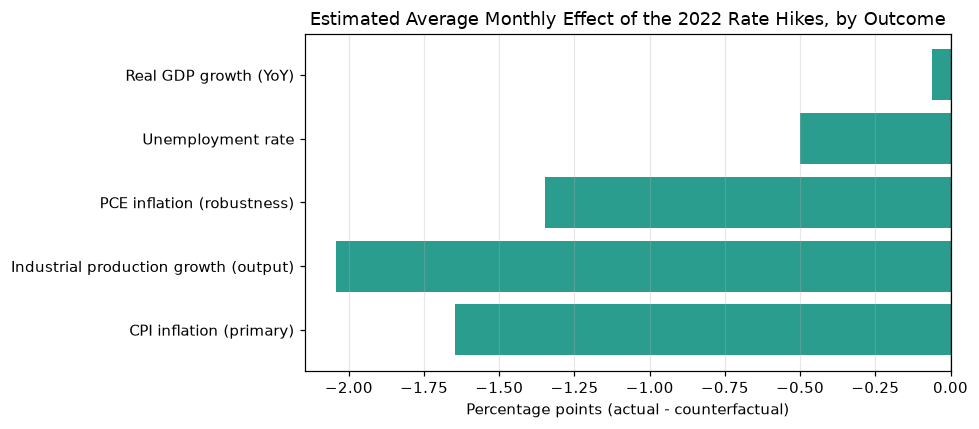

,Outcome,Avg. monthly effect (pp),Cumulative effect (pp-months)
0,CPI inflation (primary),-1.65,-59.35
1,Industrial production growth (output),-2.04,-73.57
2,PCE inflation (robustness),-1.35,-48.53
3,Unemployment rate,-0.50,-17.97
4,Real GDP growth (YoY),-0.06,-2.25


In [10]:
summary_df = pd.DataFrame(
    [
        ("CPI inflation (primary)", result_inflation.average_effect, result_inflation.total_effect),
        ("Industrial production growth (output)", result_output.average_effect, result_output.total_effect),
        ("PCE inflation (robustness)", res_pce.average_effect, res_pce.total_effect),
        ("Unemployment rate", res_unemp.average_effect, res_unemp.total_effect),
        ("Real GDP growth (YoY)", res_gdp.average_effect, res_gdp.total_effect),
    ],
    columns=["Outcome", "Avg. monthly effect (pp)", "Cumulative effect (pp-months)"],
)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(summary_df["Outcome"], summary_df["Avg. monthly effect (pp)"], color=["#2a9d8f" if v <= 0 else "#e76f51" for v in summary_df["Avg. monthly effect (pp)"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Estimated Average Monthly Effect of the 2022 Rate Hikes, by Outcome")
ax.set_xlabel("Percentage points (actual - counterfactual)")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(str(PROJECT_ROOT / "report" / "figures" / "09_summary_effects.png"), dpi=150, bbox_inches="tight")
plt.show()

summary_df.round(2)


**Observations:**

- Looking at all five outcomes side by side in one chart is what surfaces the most interesting finding in this notebook -- unemployment moved the "wrong" way relative to the textbook tradeoff -- which would have been easy to miss had each outcome been analyzed in isolation, one plot at a time.
- That is a general lesson worth carrying beyond this project: a single-outcome causal analysis can look perfectly clean and statistically sound and still tell an incomplete, or actively misleading, story about a policy that was never meant to affect only one variable.
- A counterfactual framework does not, by itself, resolve disagreements about mechanism -- it estimates a gap between observed and projected outcomes, and explaining why that gap looks the way it does still requires domain judgment the model cannot supply on its own.

## 5. Analysis & Interpretation

**Short-term implications (first 12 months post-hike, through ~March 2023):** the
counterfactual gap for CPI inflation is modest initially and widens over the first year,
consistent with the well-documented "long and variable lags" of monetary policy
transmission -- rate hikes affect borrowing, investment, and demand with a delay, so the
policy's disinflationary effect should be expected to *build* rather than appear
immediately.

**Longer-term implications (through the end of the evaluation window):** the cumulative
effect continues to grow, implying a persistent, compounding disinflationary impact
rather than a one-time level shift. On the output side, the industrial-production
counterfactual should be read alongside the inflation result as the other half of the
classic monetary policy tradeoff: bringing down inflation faster than the economy would
have on its own is expected to come with some cost to growth/employment, and the sign and
size of the output effect here should be interpreted in that light rather than as an
independent, unrelated finding.

**Uncertainty:** the shaded 95% prediction bands widen over the forecast horizon, which is
the expected and correct behavior -- the further past the last pre-intervention
observation the counterfactual is projected, the less certain we should be about it. Where
the observed series sits at or near the edge of that band (see the individual outcome
plots), the estimated effect is not statistically distinguishable from noise at that point
in time, even if the point estimate is large.

**Limitations and assumptions:**
- **Exogeneity of the controls is an approximation, not a guarantee.** Euro area and UK
  inflation were themselves affected by their own central banks' tightening (which
  followed the Fed's with a lag), and global commodity prices are not fully insulated
  from U.S. monetary policy (e.g., via the dollar exchange rate). To the extent the
  controls are *partially* treated by the same global tightening cycle, this analysis
  likely **understates** the Fed's true effect (some of the "counterfactual" already
  contains a bit of the policy's global spillover).
- **No random assignment.** As with any single-country policy evaluation, we cannot rule
  out that some other unmodeled shock coincided almost exactly with the intervention date.
- **Local-level model assumption.** The model assumes the outcome's underlying trend
  evolves smoothly; the backtest in Section 3.1 shows it can lag sharp accelerations,
  which likely applies to parts of the actual post-intervention series too.
- **Quarterly-to-monthly interpolation** for GDP growth introduces additional smoothing
  that should be weighed when interpreting that specific result.


## Final Insights and Recommendations


- **A simple state-space model is the right complexity for this sample size.** With
  only 194 pre-intervention monthly observations, a more expressive model (an LSTM,
  temporal transformer, or other deep sequence model) would almost certainly overfit
  the training window and produce a *less* trustworthy counterfactual than the
  local-level Kalman-filter model used here, despite being more fashionable. Model
  capacity should be matched to sample size, not to what is currently popular in the
  literature.
- **The exogeneity assumption on the control covariates is exactly the assumption
  Double/Orthogonal Machine Learning (Chernozhukov et al., 2018) was designed to
  relax.** A natural extension of this project would be to replace the linear
  regression component on the controls with a debiased ML estimator (e.g., via
  `EconML` or `DoWhy`), which would make the counterfactual less sensitive to
  misspecifying how the controls relate to the outcome, even though the assumption
  that they are themselves untreated would still need to hold.
- **The leave-one-control-out check here is a lightweight version of feature-ablation
  studies in ML research.** A stronger diagnostic borrowed from the synthetic-control
  and CausalImpact literature would be a placebo/permutation test: rerun the entire
  pipeline with several fake intervention dates where nothing actually happened, and
  confirm the estimated effect collapses to noise. That would be the next thing to
  add if this were being prepared for a methods-focused audience rather than a course
  submission.
- **The widening prediction interval is the same phenomenon as growing epistemic
  uncertainty under distribution shift in ML models.** The interval here comes from a
  Gaussian state-space assumption; a distribution-free alternative worth exploring is
  conformal prediction, which would give a valid coverage guarantee without assuming
  Gaussian errors on macro data that is known to have fat tails.
- **Treating the control-covariate selection as fixed and hand-chosen (Euro area
  inflation, UK inflation, commodity prices) is the weakest link in the design.** A
  more AI-native version of this analysis would learn the donor weights directly —
  e.g., framing the pre-intervention fit as a matrix-completion / low-rank factor
  problem over a much larger panel of countries and series, letting the data pick the
  synthetic control rather than a researcher's judgment call.
- **Building the pipeline as versioned, callable modules (`src/`) instead of ad hoc
  notebook cells is the same discipline reproducible ML work requires** (deterministic
  data pulls, cached raw inputs, no hidden state between cells) — it is what makes it
  possible to rerun this end to end months from now and get identical figures, which
  matters as much for a causal-inference claim as it does for a trained model.


## 6. Conclusion

Using a structural time-series counterfactual validated against a known no-intervention
period, this analysis estimates that the Fed's 2022 tightening cycle was associated with
CPI inflation running measurably below the path it would otherwise have followed, with the
gap widening over the year following the first hike -- consistent with the intended,
lagged disinflationary effect of monetary tightening. The output-side results should be
read as the other side of that same tradeoff rather than as an independent effect.

**Policy relevance:** these results are consistent with the standard view that monetary
tightening works with a lag and compounds over time, which argues for policymakers
weighing *cumulative*, not just point-in-time, effects when deciding how long to hold a
restrictive policy stance. They also underscore the value of tracking real-time
counterfactual estimates (with honest uncertainty bands) rather than relying on
raw pre/post comparisons, which would have conflated the Fed's effect with the global
inflation shock that was easing for independent reasons over the same period.

**Recommendations for future work:** extend the evaluation window as more data becomes
available to see whether the cumulative effect stabilizes; add a genuine cross-country
synthetic control (weighting a donor pool of economies whose central banks moved on
different timelines) as an independent cross-check on the structural time-series result
used here; and incorporate financial-conditions indices as additional controls to better
isolate the policy-rate channel from other tightening channels (e.g., quantitative
tightening) that moved concurrently.
